In [1]:
import numpy as np
import sys
sys.path.append('../../../src')
from data_loader import DataLoader
from noise_optimizers import EKF_NoiseOptimizer

%matplotlib inline
np.random.seed(777)

## Load data

In [2]:
kitti_root_dir = '../../../data'
noise_vector_dir = '../../../exports/_noise_optimizations/noise_vectors'
kitti_date = '2011_09_30'
kitti_drive = '0016'
data = DataLoader(sequence_nr=kitti_drive, 
                kitti_root_dir=kitti_root_dir, 
                noise_vector_dir=noise_vector_dir,
                vo_dropout_ratio=0.0, 
                gps_dropout_ratio=0.0,
                upsampling_factor=10,
                downsampling_ratio=0.8,
                visualize_data=False)

Data sampling is set to normal mode.


In [3]:
error_df_export_path = '../../../exports/_noise_optimizations/errors/ekf'
noise_vector_export_path = '../../../exports/_noise_optimizations/noise_vectors/ekf'

In [4]:
ekf_optimizer = EKF_NoiseOptimizer(data=data, 
                                   error_df_export_path=error_df_export_path, 
                                   noise_vector_export_path=noise_vector_export_path)

In [5]:
ekf_optimizer.compare(load_exported=True)

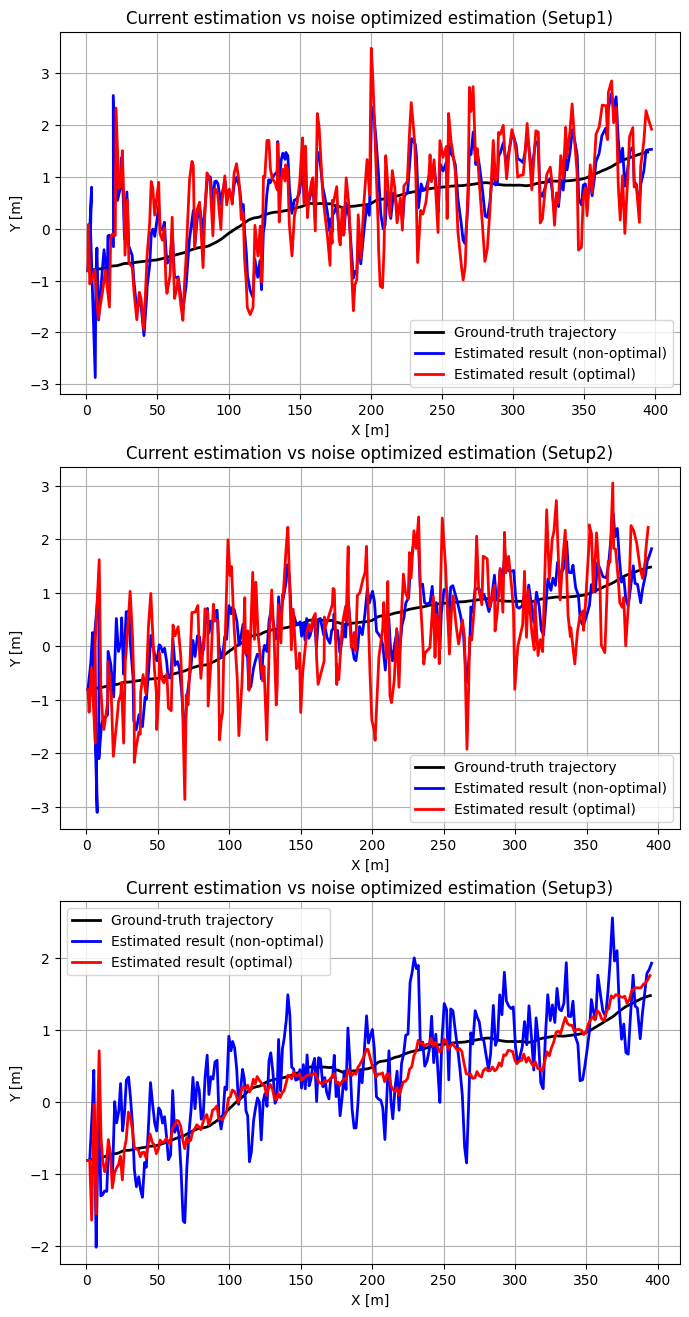

In [6]:
ekf_optimizer.visualize_results()

In [7]:
ekf_optimizer.error_df

Setups        Setup1(IMU+VO)               Setup2(IMU+VO,GPS)                \
Error types              MAE   RMSE    MAX                MAE   RMSE    MAX   
Non-optimized          0.700  0.887  3.288              0.467  0.590  2.321   
Optimized              0.832  1.050  3.991              0.657  0.838  2.761   
∆                      0.132  0.163  0.703              0.190  0.248  0.440   

Setups        Setup3(INS)                
Error types           MAE   RMSE    MAX  
Non-optimized       0.378  0.467  1.681  
Optimized           0.143  0.198  1.488  
∆                  -0.235 -0.269 -0.193